<a href="https://colab.research.google.com/github/ankit-rathi/quantvesting_v3/blob/main/notebooks/06_QUANTVESTING_BACKTEST.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<a href="https://colab.research.google.com/github/ankit-rathi/quantvesting_v3/blob/main/notebooks/quantvesting_backtest_end_to_end_v4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# from google.colab import drive
# drive.mount('/content/drive')

# Quantvesting — Strategy Prototype

### A simple, user-friendly end-to-end backtest

This notebook answers one question:

> **Does the Quantvesting strategy behave sensibly when we run it on real historical prices?**

It uses six NSE-listed securities through `yfinance`.

**Prototype assumptions**
- Market data: approximate Yahoo Finance data
- Corporate actions: ignored for now
- Signals: read from a small CSV you provide
- Backtest: daily data, EOD decision → next trading-day open entry
- This is a demonstration of the strategy mechanics, **not investment advice or production performance evidence**

---

## Your only input

Create this file next to the notebook:

`data/signals.csv`

Example:

```text
symbol,conviction
RELIANCE,X-LC
TCS,X-LC
INFY,X-LC
ITC,H-LC
HDFCBANK,H-LC
HINDALCO,H-LC
```

The notebook will automatically:
1. validate the file,
2. download the six stocks,
3. calculate running ATH and ATH Gap,
4. apply your conviction classification,
5. run the portfolio,
6. show the results in a presentation-friendly dashboard.


In [2]:
# 1. Setup
import sys, subprocess, importlib.util, warnings, math
from pathlib import Path

if importlib.util.find_spec("yfinance") is None:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "yfinance"])

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import yfinance as yf

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 50)

DATA_DIR = Path("sample_data")
SIGNAL_FILE = DATA_DIR / "signals.csv"

START_DATE = "2021-10-01"
END_DATE = "2026-09-01"

INITIAL_CAPITAL = 10_000_000       # ₹1 crore
ENTRY_ATH_GAP = 0.20
MAX_HOLDINGS = 35
MAX_POSITION_PCT = 0.03           # Never allocate more than 3% of TOTAL CORPUS to one scrip
TRANSACTION_COST_BPS = 10
SLIPPAGE_BPS = 5

print("✓ Environment ready")


✓ Environment ready


In [3]:
import sys, subprocess, importlib.util, warnings, math
from pathlib import Path

if importlib.util.find_spec("yfinance") is None:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "yfinance"])

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import yfinance as yf

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 50)

DATA_DIR = Path("sample_data")
SIGNAL_FILE = DATA_DIR / "signals.csv"

START_DATE = "2021-10-01"
END_DATE = "2026-09-01"

INITIAL_CAPITAL = 10_000_000       # ₹1 crore
ENTRY_ATH_GAP = 0.20
MAX_HOLDINGS = 35
MAX_POSITION_PCT = 0.03           # Never allocate more than 3% of TOTAL CORPUS to one scrip
TRANSACTION_COST_BPS = 10
SLIPPAGE_BPS = 5

print("✓ Environment ready")

# 2. Load and validate YOUR signal file
if not SIGNAL_FILE.exists():
    raise FileNotFoundError(
        f"Missing {SIGNAL_FILE}. Create it with columns: symbol,conviction"
    )

signals_config = pd.read_csv(SIGNAL_FILE)
signals_config.columns = [str(c).strip().lower() for c in signals_config.columns]

required = {"symbol", "conviction"}
missing = required - set(signals_config.columns)
if missing:
    raise ValueError(f"signals.csv is missing columns: {sorted(missing)}")

signals_config["symbol"] = signals_config["symbol"].astype(str).str.strip().str.upper()
signals_config["conviction"] = signals_config["conviction"].astype(str).str.strip().str.upper()

allowed = {"X-LC", "H-LC"}
bad = sorted(set(signals_config["conviction"]) - allowed)
if bad:
    raise ValueError(f"Unsupported conviction values: {bad}. Use X-LC or H-LC.")

if signals_config["symbol"].duplicated().any():
    dupes = signals_config.loc[signals_config["symbol"].duplicated(), "symbol"].tolist()
    raise ValueError(f"Duplicate symbols in signals.csv: {dupes}")

# Filter out 'LTIM' as its data download previously failed.
signals_config = signals_config[signals_config['symbol'] != 'LTIM'].reset_index(drop=True)
print("✓ Removed 'LTIM' from signals_config due to previous data download failure.")

#if len(signals_config) != 6:
#    raise ValueError(f"Expected 6 securities, found {len(signals_config)}.")

YF_TICKERS = {f"{s}.NS": s for s in signals_config["symbol"]}

print("✓ Signal file loaded")
print()
display(signals_config.style.hide(axis="index"))

✓ Environment ready
✓ Removed 'LTIM' from signals_config due to previous data download failure.
✓ Signal file loaded



symbol,conviction
BSE,X-LC
BAJAJ-AUTO,X-LC
HDFCAMC,X-LC
M&M,X-LC
HEROMOTOCO,H-LC
BHARTIARTL,H-LC
SIEMENS,H-LC
BOSCHLTD,X-LC
ADANIPORTS,X-LC
TORNTPHARM,H-LC


## 1. Your strategy universe

The CSV above is deliberately kept separate from market data.

That means later we can replace the CSV with the **real historical Quantvesting signal snapshots** without changing the backtest engine.

For this prototype, the six classifications are treated as the user's supplied strategy universe.


In [4]:
# 3. Download market data
market_download_end = (pd.Timestamp(END_DATE) + pd.Timedelta(days=1)).strftime("%Y-%m-%d")
raw = yf.download(
    list(YF_TICKERS.keys()),
    start=START_DATE,
    end=market_download_end,
    interval="1d",
    auto_adjust=False,
    actions=False,
    progress=False,
    repair=True,
    group_by="column",
)

if raw is None or raw.empty:
    raise RuntimeError("No market data returned by yfinance.")

frames = []
for yf_ticker, symbol in YF_TICKERS.items():
    if isinstance(raw.columns, pd.MultiIndex):
        if yf_ticker in raw.columns.get_level_values(-1):
            sub = raw.xs(yf_ticker, axis=1, level=-1, drop_level=True).copy()
        elif yf_ticker in raw.columns.get_level_values(0):
            sub = raw.xs(yf_ticker, axis=1, level=0, drop_level=True).copy()
        else:
            continue
    else:
        sub = raw.copy()

    sub = sub.rename(columns={c: str(c).title() for c in sub.columns})
    needed = ["Open", "High", "Low", "Close", "Volume"]
    missing_cols = [c for c in needed if c not in sub.columns]
    if missing_cols:
        raise ValueError(f"{symbol}: missing {missing_cols}")

    sub = sub[needed].copy()
    sub["date"] = pd.to_datetime(sub.index).tz_localize(None)
    sub["symbol"] = symbol
    frames.append(sub.reset_index(drop=True))

prices = pd.concat(frames, ignore_index=True)
prices = prices[["date","symbol","Open","High","Low","Close","Volume"]]
prices = prices.sort_values(["symbol","date"]).reset_index(drop=True)

print(f"✓ Downloaded {len(prices):,} daily observations")
print(f"  {prices['date'].min():%d %b %Y} → {prices['date'].max():%d %b %Y}")


✓ Downloaded 63,388 daily observations
  01 Oct 2021 → 01 Sep 2026


In [5]:
# 4. Data health — compact user-facing check
quality = {
    "Duplicate rows": int(prices.duplicated(["symbol","date"]).sum()),
    "Missing prices": int(prices[["Open","High","Low","Close"]].isna().any(axis=1).sum()),
    "Non-positive prices": int((prices[["Open","High","Low","Close"]] <= 0).any(axis=1).sum()),
    "Invalid OHLC rows": int((
        (prices["Low"] > prices["Open"]) |
        (prices["Low"] > prices["Close"]) |
        (prices["Low"] > prices["High"]) |
        (prices["High"] < prices["Open"]) |
        (prices["High"] < prices["Close"])
    ).sum())
}

quality_df = pd.DataFrame(
    [{"Check": k, "Issues": v, "Status": "✓ OK" if v == 0 else "⚠ Review"} for k,v in quality.items()]
)

display(quality_df.style.hide(axis="index"))


Check,Issues,Status
Duplicate rows,0,✓ OK
Missing prices,1377,⚠ Review
Non-positive prices,0,✓ OK
Invalid OHLC rows,0,✓ OK


## 2. The key strategy signal

For every stock and every day we calculate:

**ATH Gap = (Running ATH − Current Close) / Current Close**

Example:

- Running ATH = ₹1,000
- Current price = ₹800
- ATH Gap = 25%

So the stock has **25% upside to its running ATH**.

The strategy looks for conviction (`X-LC` or `H-LC`) **and** sufficient ATH Gap.


In [6]:
prices["running_ath"] = prices.groupby("symbol")["High"].cummax()
prices["ath_gap"] = (prices["running_ath"] - prices["Close"]) / prices["Close"]

conviction_map = dict(zip(signals_config["symbol"], signals_config["conviction"]))
prices["conviction"] = prices["symbol"].map(conviction_map)

# Map conviction to a numerical rank for sorting candidates
conviction_rank_map = {
    "X-LC": 1, # Assign lower rank for higher priority / conviction
    "H-LC": 2,
}
prices["rank"] = prices["conviction"].map(conviction_rank_map)

prices["next_date"] = prices.groupby("symbol")["date"].shift(-1)
prices["next_open"] = prices.groupby("symbol")["Open"].shift(-1)

latest = (
    prices.sort_values("date")
    .groupby("symbol")
    .tail(1)[["symbol","date","Close","running_ath","ath_gap","conviction"]]
    .sort_values("ath_gap", ascending=False)
)

latest_display = latest.copy()
latest_display["date"] = latest_display["date"].dt.strftime("%d %b %Y")
latest_display["Close"] = latest_display["Close"].map(lambda x: f"₹{x:,.2f}")
latest_display["running_ath"] = latest_display["running_ath"].map(lambda x: f"₹{x:,.2f}")
latest_display["ath_gap"] = latest_display["ath_gap"].map(lambda x: f"{x:.1%}")

display(latest_display.style.hide(axis="index"))

symbol,date,Close,running_ath,ath_gap,conviction
TMPV,01 Sep 2026,₹310.00,"₹1,179.00",280.3%,X-LC
TCS,01 Sep 2026,"₹2,369.00","₹4,592.25",93.8%,X-LC
ITC,01 Sep 2026,₹266.60,₹508.90,90.9%,X-LC
INFY,01 Sep 2026,"₹1,156.00","₹2,006.45",73.6%,X-LC
GODREJCP,01 Sep 2026,₹905.00,"₹1,541.85",70.4%,X-LC
VBL,01 Sep 2026,₹405.85,₹681.12,67.8%,X-LC
JIOFIN,01 Sep 2026,₹235.85,₹394.70,67.4%,X-LC
DMART,01 Sep 2026,"₹3,824.00","₹5,900.00",54.3%,X-LC
HINDUNILVR,01 Sep 2026,"₹1,994.80","₹3,035.00",52.1%,X-LC
HDFCLIFE,01 Sep 2026,₹540.30,₹820.75,51.9%,X-LC


## 3. Backtest engine

### Event order

**End of day T**
→ calculate today's signal  
→ freeze today's running ATH  
→ select candidates

**Next trading day T+1**
→ buy at the opening price

While holding:
→ if today's High reaches the **frozen entry ATH**, exit

This separation is important: the strategy never gets to see tomorrow's open when making today's decision.


In [7]:
# 6. Backtest engine — corpus-aware position sizing
def run_backtest(prices, initial_capital=INITIAL_CAPITAL):
    """
    Event-driven backtest.

    Important accounting rules:
    - MAX_HOLDINGS is a cap on concurrent positions.
    - Each new scrip is capped at MAX_POSITION_PCT of the TOTAL CORPUS
      (cash + marked-to-market invested value) known before the trade.
    - Cash is never allowed to go negative; total invested capital can never
      exceed the available corpus/cash.
    - A missing/unavailable scrip simply cannot be bought until it has a
      valid next trading day/open. Its capital remains cash.
    - EOD signals are executed at the next available trading-day open for
      that same scrip.
    - Existing frozen-ATH exit logic is retained.
    """
    df = prices.sort_values(["date", "symbol"]).copy()
    dates = sorted(df["date"].unique())

    cash = float(initial_capital)
    positions = {}
    pending_entries = {}
    trades = []
    last_close = {}
    daily = []

    cost_rate = TRANSACTION_COST_BPS / 10_000
    slip_rate = SLIPPAGE_BPS / 10_000

    for date in dates:
        day = df[df["date"] == date].set_index("symbol")

        # A) Execute yesterday's EOD decisions at today's open.
        # Position sizing is based on the latest known TOTAL CORPUS:
        # prior EOD cash + prior EOD marked-to-market holdings.
        scheduled = sorted(
            pending_entries.pop(date, []),
            key=lambda x: (x["rank"], x["symbol"])
        )

        for sig in scheduled:
            symbol = sig["symbol"]

            # If this scrip is unavailable today, do not reserve any capital.
            # Keep the signal alive until that scrip has its next available
            # trading day/open, then try the entry again.
            if symbol in positions:
                continue
            if symbol not in day.index:
                future_rows = df[(df["symbol"] == symbol) & (df["date"] > date)]
                if not future_rows.empty:
                    retry_date = future_rows["date"].iloc[0]
                    pending_entries.setdefault(retry_date, []).append(sig)
                continue
            if len(positions) >= MAX_HOLDINGS:
                continue

            open_px = float(day.loc[symbol, "Open"])
            if not np.isfinite(open_px) or open_px <= 0:
                continue

            # TOTAL CORPUS = cash + marked-to-market invested value at the
            # latest known EOD (before today's open). Never use today's close.
            if daily:
                corpus_before_entry = float(daily[-1]["portfolio_value"])
            else:
                corpus_before_entry = float(initial_capital)

            max_position_notional = corpus_before_entry * MAX_POSITION_PCT

            # Use the full permitted 3% where cash permits. Do NOT divide
            # available cash by remaining slots: that unnecessarily leaves
            # capital idle when more than one opportunity is available.
            target_notional = min(
                max_position_notional,
                max(0.0, cash)
            )

            entry_px = open_px * (1 + slip_rate)
            all_in_per_share = entry_px * (1 + cost_rate)

            shares = math.floor(target_notional / all_in_per_share)

            # Hard accounting guard: acquisition cost must be funded by cash.
            if shares > 0:
                notional = shares * entry_px
                cost = notional * cost_rate
                total_cash_out = notional + cost

                if total_cash_out > cash + 1e-9:
                    shares = math.floor(cash / all_in_per_share)
                    notional = shares * entry_px
                    cost = notional * cost_rate
                    total_cash_out = notional + cost
            else:
                notional = 0.0
                cost = 0.0
                total_cash_out = 0.0

            if shares <= 0 or total_cash_out > cash + 1e-9:
                continue

            cash_before = cash
            invested_before = corpus_before_entry - cash_before
            cash -= total_cash_out

            positions[symbol] = {
                "entry_date": date,
                "signal_date": sig["signal_date"],
                "entry_price": entry_px,
                "shares": shares,
                "entry_ath": sig["signal_ath"],
                "conviction": sig["conviction"],
                "rank": sig["rank"],
            }

            trades.append({
                "date": date,
                "event": "ENTRY",
                "symbol": symbol,
                "price": entry_px,
                "shares": shares,
                "notional": notional,
                "cost": cost,
                "portfolio_value_before_entry": corpus_before_entry,
                "cash_before_entry": cash_before,
                "invested_value_before_entry": invested_before,
                "max_position_notional": max_position_notional,
                "position_pct_before_entry": (
                    notional / corpus_before_entry
                    if corpus_before_entry else np.nan
                ),
                "cash_after_entry": cash,
                "total_cash_out": total_cash_out,
                "reason": "EOD signal → T+1 open",
                "signal_date": sig["signal_date"],
                "entry_ath": sig["signal_ath"],
                "conviction": sig["conviction"],
                "rank": sig["rank"],
            })

        # Refresh the last known close for every security that traded today.
        for _symbol, _row in day.iterrows():
            _close = float(_row["Close"])
            if np.isfinite(_close) and _close > 0:
                last_close[_symbol] = _close

        # B) Check frozen ATH exits.
        # Exits remain after T+1 entries because today's High is only known
        # after today's market session; using exit proceeds for today's open
        # would introduce look-ahead bias.
        for symbol in list(positions):
            if symbol not in day.index:
                continue

            pos = positions[symbol]
            high_px = float(day.loc[symbol, "High"])

            if high_px >= pos["entry_ath"]:
                exit_px = pos["entry_ath"] * (1 - slip_rate)
                notional = pos["shares"] * exit_px
                cost = notional * cost_rate
                cash += notional - cost

                trades.append({
                    "date": date,
                    "event": "EXIT",
                    "symbol": symbol,
                    "price": exit_px,
                    "shares": pos["shares"],
                    "notional": notional,
                    "cost": cost,
                    "reason": "Frozen entry ATH reached",
                    "signal_date": pos["signal_date"],
                    "entry_ath": pos["entry_ath"],
                    "conviction": pos["conviction"],
                    "rank": pos["rank"],
                })
                del positions[symbol]

        # C) Today's EOD signal → schedule tomorrow's entry.
        # If a constituent is not yet listed / has no next trading date,
        # nothing is reserved and the capital stays in cash.
        slots = MAX_HOLDINGS - len(positions)

        if slots > 0:
            candidates = (
                df[
                    (df["date"] == date) &
                    (df["conviction"].isin(["X-LC", "H-LC"])) &
                    (df["ath_gap"] >= ENTRY_ATH_GAP) &
                    (~df["symbol"].isin(positions.keys()))
                ]
                .sort_values(["rank", "symbol"])
                .head(slots)
            )

            for _, row in candidates.iterrows():
                if pd.isna(row["next_date"]):
                    continue

                pending_entries.setdefault(row["next_date"], []).append({
                    "symbol": row["symbol"],
                    "signal_date": date,
                    "signal_ath": float(row["running_ath"]),
                    "conviction": row["conviction"],
                    "rank": int(row["rank"]),
                })

        # D) Mark portfolio to market.
        invested = 0.0
        for symbol, pos in positions.items():
            close_px = last_close.get(symbol)
            if close_px is not None and np.isfinite(close_px) and close_px > 0:
                invested += pos["shares"] * close_px

        corpus = cash + invested

        # Accounting invariant: cash cannot be negative and invested value
        # cannot exceed total corpus by construction.
        if cash < -1e-7:
            raise AssertionError(f"Negative cash on {date}: {cash}")
        if invested > corpus + 1e-7:
            raise AssertionError(f"Invested value exceeds corpus on {date}")

        daily.append({
            "date": date,
            "cash": cash,
            "invested_value": invested,
            "portfolio_value": corpus,
            "open_positions": len(positions),
            "cash_pct": cash / corpus if corpus else np.nan,
            "invested_pct": invested / corpus if corpus else np.nan,
        })

    return pd.DataFrame(daily), pd.DataFrame(trades)


portfolio, trades = run_backtest(prices)

print(f"✓ Backtest completed: {len(portfolio):,} trading days")
print(f"✓ Trade events generated: {len(trades):,}")


✓ Backtest completed: 1,219 trading days
✓ Trade events generated: 250


In [8]:
# 7. User-friendly headline results
portfolio["peak"] = portfolio["portfolio_value"].cummax()
portfolio["drawdown"] = portfolio["portfolio_value"] / portfolio["peak"] - 1

ending = float(portfolio["portfolio_value"].iloc[-1])
total_return = ending / INITIAL_CAPITAL - 1
years = (portfolio["date"].iloc[-1] - portfolio["date"].iloc[0]).days / 365.25
cagr = (ending / INITIAL_CAPITAL) ** (1 / years) - 1 if years > 0 else np.nan
max_dd = float(portfolio["drawdown"].min())

entries = trades[trades["event"] == "ENTRY"].copy() if not trades.empty else pd.DataFrame()
exits = trades[trades["event"] == "EXIT"].copy() if not trades.empty else pd.DataFrame()

# KPI cards as a clean table rather than raw Series output.
kpis = pd.DataFrame([[
    f"₹{INITIAL_CAPITAL/1e7:.1f} Cr",
    f"₹{ending/1e7:.2f} Cr",
    f"{total_return:.1%}",
    f"{cagr:.1%}",
    f"{max_dd:.1%}",
    f"{len(entries)}",
    f"{len(exits)}",
]], columns=[
    "Starting Capital","Ending Value","Total Return","CAGR",
    "Max Drawdown","Entries","Exits"
])

display(kpis.style
        .hide(axis="index")
        .set_properties(**{"font-size":"14pt","font-weight":"bold","text-align":"center"})
        .set_table_styles([
            {"selector":"th","props":[("text-align","center"),("font-size","11pt")]},
            {"selector":"td","props":[("padding","12px"),("text-align","center")]}
        ]))


Starting Capital,Ending Value,Total Return,CAGR,Max Drawdown,Entries,Exits
₹1.0 Cr,₹1.69 Cr,69.5%,11.3%,-13.3%,142,108


# 4. The result

The chart below is the main user-facing output.

It answers:

> **If ₹1 crore had followed these rules over the selected historical period, how did the portfolio value evolve?**

The return number alone is not enough. The shape of the curve and the drawdowns matter too.


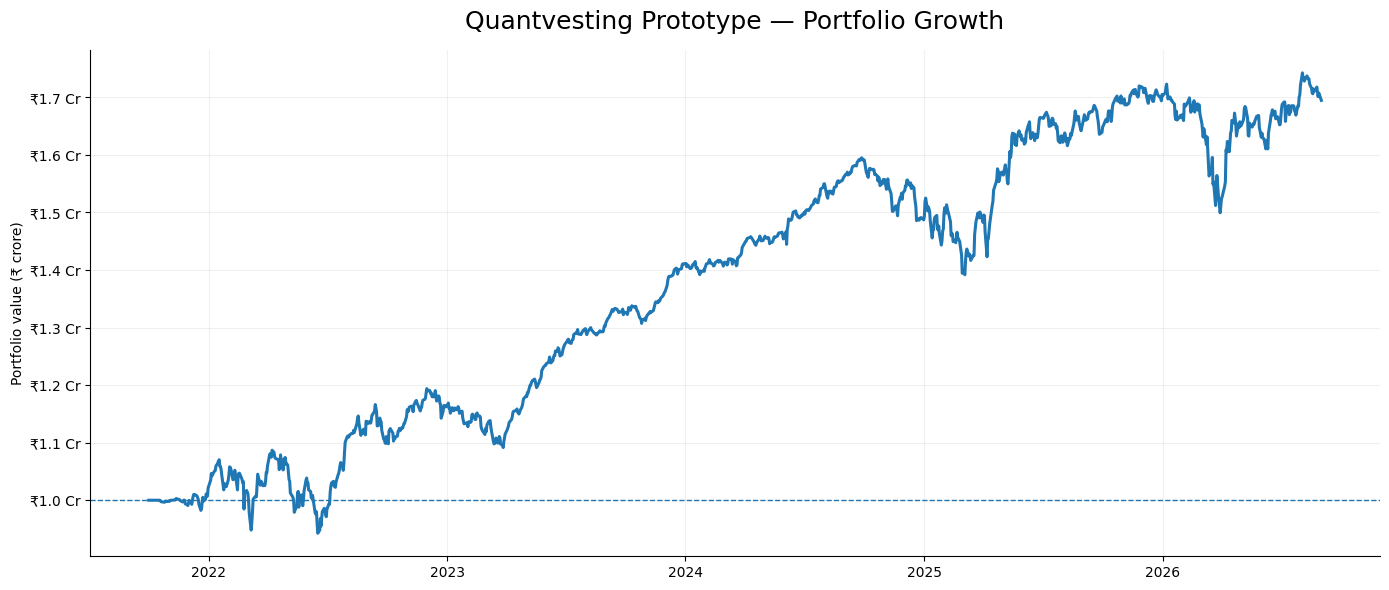

In [9]:
# 8. Portfolio growth — presentation chart
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(portfolio["date"], portfolio["portfolio_value"] / 1e7, linewidth=2.2)

ax.axhline(INITIAL_CAPITAL / 1e7, linestyle="--", linewidth=1)
ax.set_title("Quantvesting Prototype — Portfolio Growth", fontsize=18, pad=15)
ax.set_ylabel("Portfolio value (₹ crore)")
ax.set_xlabel("")
ax.grid(alpha=0.18)
ax.spines[["top","right"]].set_visible(False)

ax.yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"₹{x:.1f} Cr"))
fig.tight_layout()
plt.show()


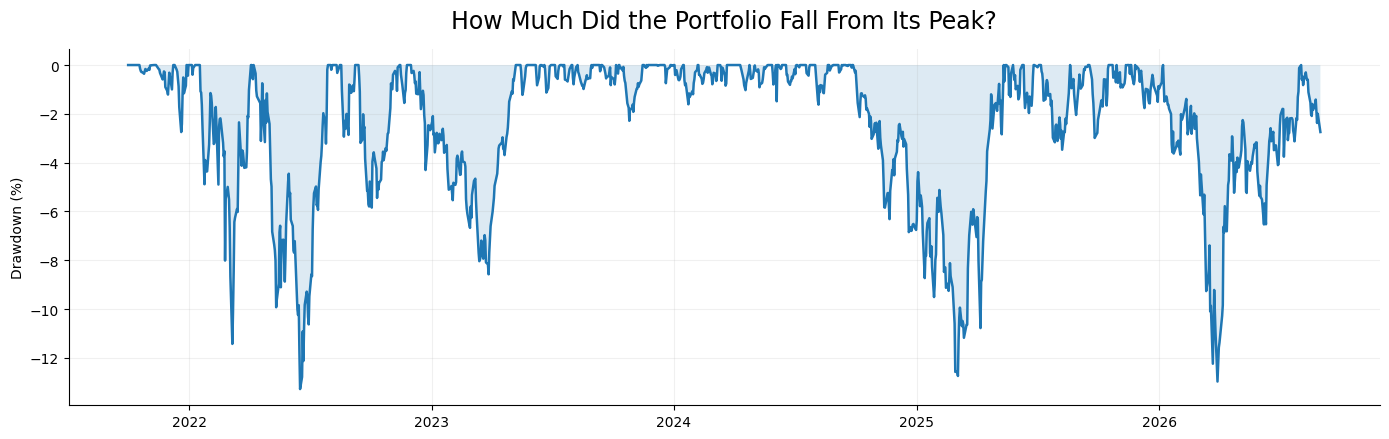

In [10]:
# 9. Drawdown — presentation chart
fig, ax = plt.subplots(figsize=(14, 4.5))
ax.plot(portfolio["date"], portfolio["drawdown"] * 100, linewidth=1.8)
ax.fill_between(portfolio["date"], portfolio["drawdown"] * 100, 0, alpha=0.15)

ax.set_title("How Much Did the Portfolio Fall From Its Peak?", fontsize=17, pad=15)
ax.set_ylabel("Drawdown (%)")
ax.set_xlabel("")
ax.grid(alpha=0.18)
ax.spines[["top","right"]].set_visible(False)

fig.tight_layout()
plt.show()


# 5. What the strategy actually did

The next view is intentionally about **behaviour**, not just performance.

Each dot represents an entry. This makes it easy to answer questions such as:

- Which stocks generated entries?
- How frequently did the strategy rotate?
- Were positions held for a few days or months?
- Are exits happening at the frozen ATH as intended?


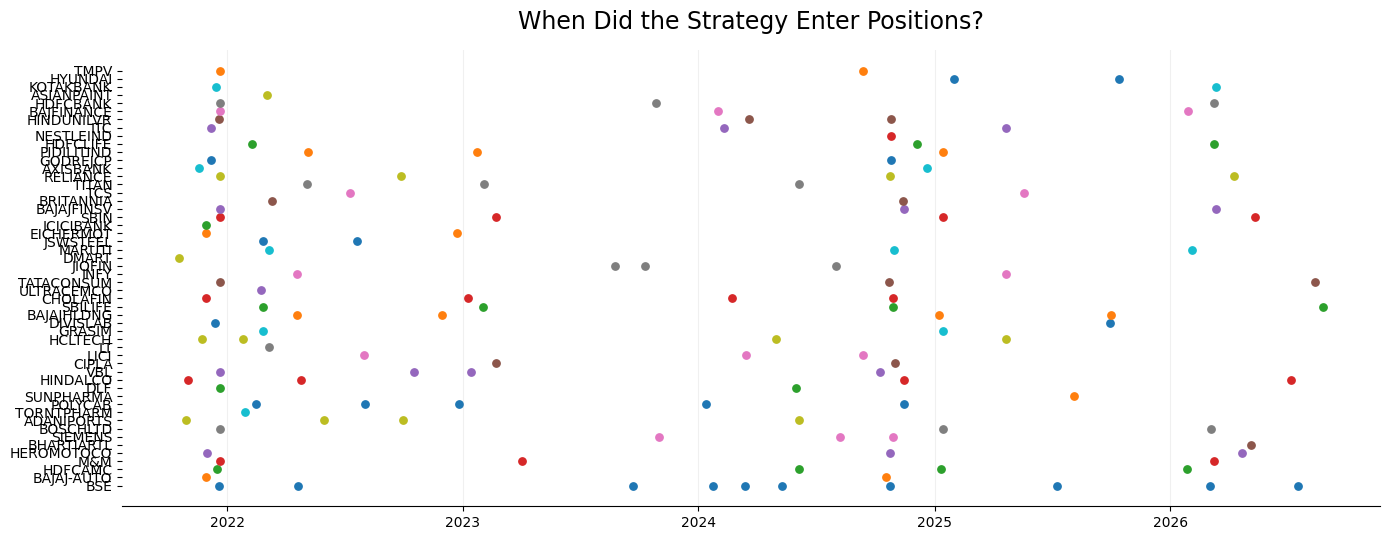

In [11]:
# 10. Entry / exit activity
if trades.empty:
    print("No trades were generated.")
else:
    events = trades.copy()
    events["date"] = pd.to_datetime(events["date"])

    symbols = list(TICKERS.values()) if "TICKERS" in globals() else list(signals_config["symbol"])
    symbol_order = {s:i for i,s in enumerate(symbols)}

    fig, ax = plt.subplots(figsize=(14, 5.5))

    for symbol in symbols:
        e = events[(events["symbol"] == symbol) & (events["event"] == "ENTRY")]
        x = e["date"]
        y = [symbol_order[symbol]] * len(e)
        ax.scatter(x, y, s=28, label=symbol)

    ax.set_yticks(range(len(symbols)))
    ax.set_yticklabels(symbols)
    ax.set_title("When Did the Strategy Enter Positions?", fontsize=17, pad=15)
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.grid(axis="x", alpha=0.18)
    ax.spines[["top","right","left"]].set_visible(False)

    fig.tight_layout()
    plt.show()


In [12]:
# 11. Trade ledger — clean inspection table
if trades.empty:
    print("No trades.")
else:
    ledger = trades.sort_values(["date","event","symbol"]).copy()
    ledger["date"] = pd.to_datetime(ledger["date"]).dt.strftime("%d %b %Y")
    ledger["signal_date"] = pd.to_datetime(ledger["signal_date"]).dt.strftime("%d %b %Y")
    ledger["price"] = ledger["price"].map(lambda x: f"₹{x:,.2f}")
    ledger["notional"] = ledger["notional"].map(lambda x: f"₹{x:,.0f}")
    ledger["cost"] = ledger["cost"].map(lambda x: f"₹{x:,.0f}")
    ledger = ledger[[
        "date","event","symbol","conviction","rank",
        "price","shares","notional","reason","signal_date","entry_ath"
    ]]
    ledger["entry_ath"] = ledger["entry_ath"].map(lambda x: f"₹{x:,.2f}")

    display(ledger.style.hide(axis="index"))


date,event,symbol,conviction,rank,price,shares,notional,reason,signal_date,entry_ath
19 Oct 2021,ENTRY,DMART,X-LC,1,"₹5,002.50",59,"₹295,148",EOD signal → T+1 open,18 Oct 2021,"₹5,900.00"
29 Oct 2021,ENTRY,ADANIPORTS,X-LC,1,₹697.35,428,"₹298,465",EOD signal → T+1 open,28 Oct 2021,₹829.90
01 Nov 2021,ENTRY,HINDALCO,H-LC,2,₹464.03,644,"₹298,837",EOD signal → T+1 open,29 Oct 2021,₹551.85
18 Nov 2021,ENTRY,AXISBANK,X-LC,1,₹715.36,419,"₹299,735",EOD signal → T+1 open,17 Nov 2021,₹866.90
23 Nov 2021,ENTRY,HCLTECH,X-LC,1,"₹1,105.55",270,"₹298,499",EOD signal → T+1 open,22 Nov 2021,"₹1,338.00"
29 Nov 2021,ENTRY,BAJAJ-AUTO,X-LC,1,"₹3,322.66",89,"₹295,717",EOD signal → T+1 open,26 Nov 2021,"₹4,050.00"
29 Nov 2021,ENTRY,CHOLAFIN,H-LC,2,₹545.07,546,"₹297,610",EOD signal → T+1 open,26 Nov 2021,₹667.40
29 Nov 2021,ENTRY,EICHERMOT,X-LC,1,"₹2,435.12",122,"₹297,084",EOD signal → T+1 open,26 Nov 2021,"₹2,959.75"
29 Nov 2021,ENTRY,ICICIBANK,X-LC,1,₹727.11,409,"₹297,389",EOD signal → T+1 open,26 Nov 2021,₹867.00
01 Dec 2021,ENTRY,HEROMOTOCO,H-LC,2,"₹2,481.24",119,"₹295,268",EOD signal → T+1 open,30 Nov 2021,"₹2,950.00"


## 5A. Transaction cross-check, apples-to-apples benchmarks & decision dashboard

This section is additive. It does not replace the existing backtest engine, result calculations, drawdown view, activity view, or sensitivity analysis.

### Position-size guardrail

The strategy allows up to `MAX_HOLDINGS` concurrent positions, currently **35**, while enforcing a hard **3% maximum allocation to any single scrip at entry**. The effective number of positions is naturally limited by the available universe.

### Apples-to-apples comparison

All three approaches are rebased to the **same common investable start date**: the first date on which the complete Quantvesting universe has usable prices and the Nifty 50 data also exists within the backtest window. The comparison capital is the same `INITIAL_CAPITAL` for all three approaches on that common date. The Quantvesting strategy is re-run from that date with the same existing rules; the original backtest remains untouched.

1. Quantvesting Strategy — existing rules and transaction costs/slippage.
2. Nifty 50 — 100% buy & hold from the common start date.
3. Quantvesting Universe — equal-weight buy & hold across the exact securities in `signals.csv` from the same common start date.

### Decision-oriented analysis

In addition to ending value and CAGR, the notebook now exposes: trade-level exit returns, strategy-vs-benchmark wealth gap, time spent invested/cash, trade frequency, completed-trade hit rate, average winning/losing exit return, and a visual wealth-gap view. These are descriptive diagnostics—not a recommendation.


A. Completed position ledger — net profit on every exited position


Symbol,Buy Date,Sell Date,Shares,Buy Price,Sell Price,Buy Cost,Sell Proceeds,Trade P/L,Exit Profit %,Holding Days,Buy Reason,Sell Reason
HCLTECH,23 Nov 2021,03 Jan 2022,270,"₹1,105.55","₹1,337.33","₹298,798","₹360,718","₹61,921",20.72%,41,EOD signal → T+1 open,Frozen entry ATH reached
CHOLAFIN,29 Nov 2021,24 Jan 2022,546,₹545.07,₹667.07,"₹297,907","₹363,854","₹65,947",22.14%,56,EOD signal → T+1 open,Frozen entry ATH reached
SBIN,21 Dec 2021,01 Feb 2022,643,₹457.28,₹542.03,"₹294,324","₹348,176","₹53,852",18.30%,42,EOD signal → T+1 open,Frozen entry ATH reached
HINDALCO,01 Nov 2021,10 Feb 2022,644,₹464.03,₹551.57,"₹299,135","₹354,858","₹55,723",18.63%,101,EOD signal → T+1 open,Frozen entry ATH reached
BSE,20 Dec 2021,10 Mar 2022,1408,₹211.22,₹263.61,"₹297,690","₹370,795","₹73,105",24.56%,80,EOD signal → T+1 open,Frozen entry ATH reached
JSWSTEEL,25 Feb 2022,28 Mar 2022,511,₹576.44,₹726.94,"₹294,854","₹371,093","₹76,239",25.86%,31,EOD signal → T+1 open,Frozen entry ATH reached
ADANIPORTS,29 Oct 2021,05 Apr 2022,428,₹697.35,₹829.49,"₹298,764","₹354,665","₹55,901",18.71%,158,EOD signal → T+1 open,Frozen entry ATH reached
ITC,07 Dec 2021,08 Apr 2022,1411,₹210.89,₹255.33,"₹297,860","₹359,916","₹62,056",20.83%,122,EOD signal → T+1 open,Frozen entry ATH reached
VBL,21 Dec 2021,13 Apr 2022,2659,₹110.72,₹135.40,"₹294,704","₹359,666","₹64,962",22.04%,113,EOD signal → T+1 open,Frozen entry ATH reached
RELIANCE,21 Dec 2021,21 Apr 2022,275,"₹1,067.22","₹1,269.11","₹293,779","₹348,657","₹54,878",18.68%,121,EOD signal → T+1 open,Frozen entry ATH reached



B. All strategy trade events — chronological BUY / SELL cross-check


Date,Action,Symbol,Shares,Price,Value,Cost,Position %,Reason,Signal Date,Conviction,Rank
19 Oct 2021,BUY,DMART,59,"₹5,002.50","₹295,148",₹295,2.95%,EOD signal → T+1 open,2021-10-18 00:00:00,X-LC,1
29 Oct 2021,BUY,ADANIPORTS,428,₹697.35,"₹298,465",₹298,2.99%,EOD signal → T+1 open,2021-10-28 00:00:00,X-LC,1
01 Nov 2021,BUY,HINDALCO,644,₹464.03,"₹298,837",₹299,3.00%,EOD signal → T+1 open,2021-10-29 00:00:00,H-LC,2
18 Nov 2021,BUY,AXISBANK,419,₹715.36,"₹299,735",₹300,2.99%,EOD signal → T+1 open,2021-11-17 00:00:00,X-LC,1
23 Nov 2021,BUY,HCLTECH,270,"₹1,105.55","₹298,499",₹298,2.99%,EOD signal → T+1 open,2021-11-22 00:00:00,X-LC,1
29 Nov 2021,BUY,BAJAJ-AUTO,89,"₹3,322.66","₹295,717",₹296,2.98%,EOD signal → T+1 open,2021-11-26 00:00:00,X-LC,1
29 Nov 2021,BUY,CHOLAFIN,546,₹545.07,"₹297,610",₹298,2.99%,EOD signal → T+1 open,2021-11-26 00:00:00,H-LC,2
29 Nov 2021,BUY,EICHERMOT,122,"₹2,435.12","₹297,084",₹297,2.99%,EOD signal → T+1 open,2021-11-26 00:00:00,X-LC,1
29 Nov 2021,BUY,ICICIBANK,409,₹727.11,"₹297,389",₹297,2.99%,EOD signal → T+1 open,2021-11-26 00:00:00,X-LC,1
01 Dec 2021,BUY,HEROMOTOCO,119,"₹2,481.24","₹295,268",₹295,2.98%,EOD signal → T+1 open,2021-11-30 00:00:00,H-LC,2



C. TRUE APPLES-TO-APPLES PERFORMANCE COMPARISON
Common start date: 01 Oct 2021
Common end date:   01 Sep 2026
Initial corpus:    ₹1.00 Cr



Approach,Initial Value,Final Value,Profit / (Loss),Total Return,CAGR,Max Drawdown,Transactions,Exits
Quantvesting Strategy,₹1.00 Cr,₹1.69 Cr,₹0.69 Cr,69.5%,11.3%,-13.3%,250,108
Nifty 50 — Buy & Hold,₹1.00 Cr,₹1.37 Cr,₹0.37 Cr,37.2%,6.6%,-17.2%,1,0
Quantvesting Universe — Equal Weight Buy & Hold,₹1.00 Cr,₹2.24 Cr,₹1.24 Cr,124.0%,17.8%,-16.7%,52,0


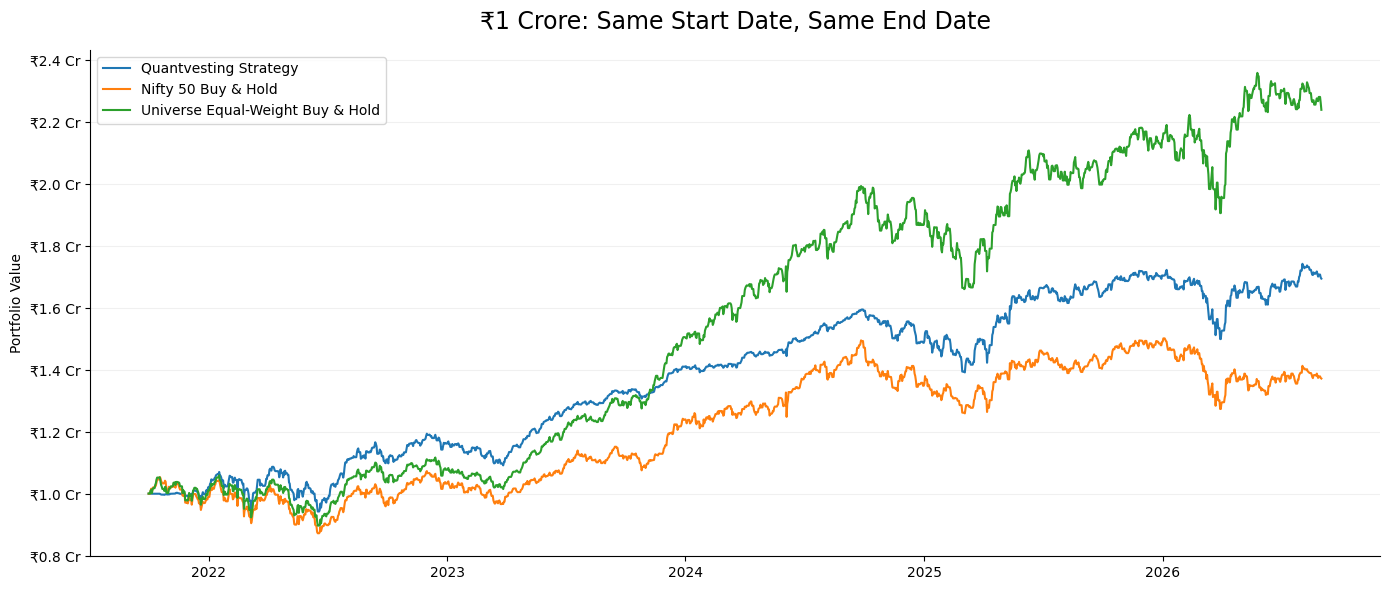

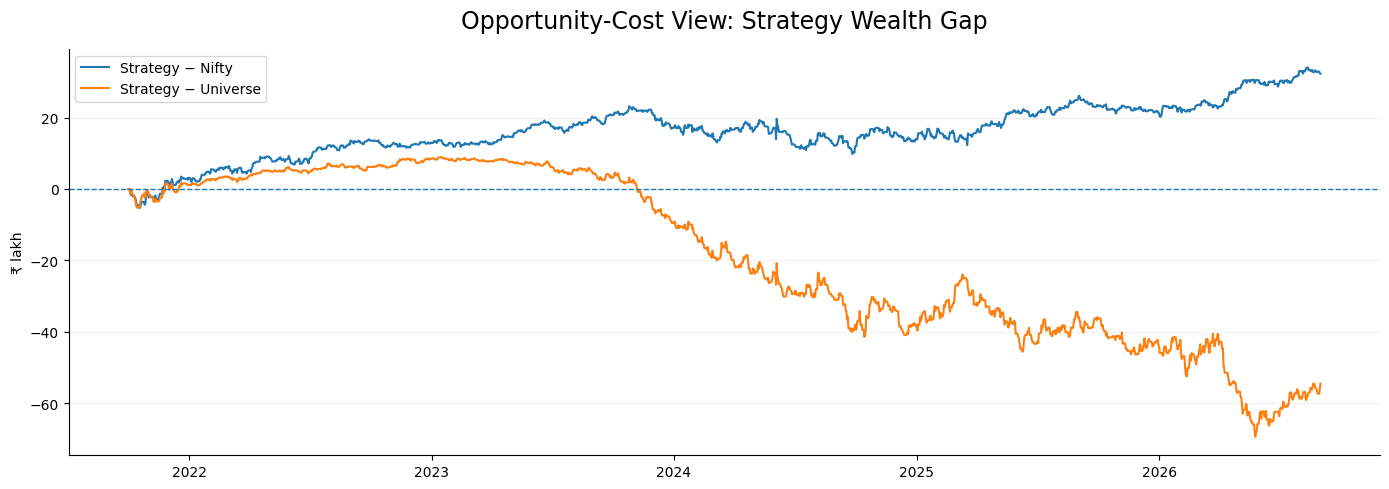

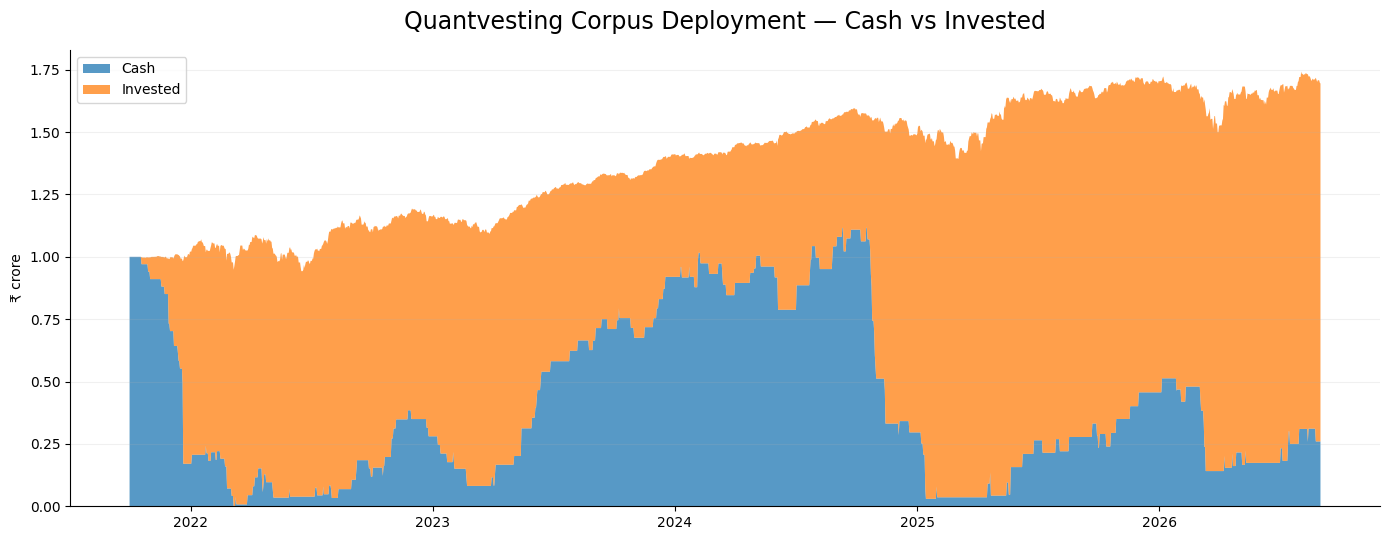


D. Corpus accounting checks
Maximum observed invested / corpus: 99.96%
Minimum observed cash: ₹3,632
Maximum observed single-scrip entry allocation: 3.00%

E. Quantvesting Universe availability at the common start


Symbol,Available at common start,First available date,Initial equal-weight slice,Treatment
BSE,Yes,01 Oct 2021,"₹192,308",Invest at start
BAJAJ-AUTO,Yes,01 Oct 2021,"₹192,308",Invest at start
HDFCAMC,Yes,01 Oct 2021,"₹192,308",Invest at start
M&M,Yes,01 Oct 2021,"₹192,308",Invest at start
HEROMOTOCO,Yes,01 Oct 2021,"₹192,308",Invest at start
BHARTIARTL,Yes,01 Oct 2021,"₹192,308",Invest at start
SIEMENS,Yes,01 Oct 2021,"₹192,308",Invest at start
BOSCHLTD,Yes,01 Oct 2021,"₹192,308",Invest at start
ADANIPORTS,Yes,01 Oct 2021,"₹192,308",Invest at start
TORNTPHARM,Yes,01 Oct 2021,"₹192,308",Invest at start


In [13]:
# 14. Transaction ledger + true apples-to-apples comparison

# ---- A. Pair each ENTRY with the next EXIT for the same symbol ----
if trades.empty:
    trade_pairs = pd.DataFrame()
else:
    tx = trades.sort_values(["symbol", "date", "event"]).copy()
    open_trades = {}
    paired = []

    for _, tr in tx.iterrows():
        symbol = tr["symbol"]
        if tr["event"] == "ENTRY":
            open_trades[symbol] = tr.to_dict()
        elif tr["event"] == "EXIT" and symbol in open_trades:
            entry = open_trades.pop(symbol)
            buy_date = pd.Timestamp(entry["date"])
            sell_date = pd.Timestamp(tr["date"])
            buy_cost = float(entry["notional"]) + float(entry["cost"])
            sell_proceeds = float(tr["notional"]) - float(tr["cost"])
            pnl = sell_proceeds - buy_cost
            paired.append({
                "Symbol": symbol,
                "Buy Date": buy_date,
                "Sell Date": sell_date,
                "Shares": int(entry["shares"]),
                "Buy Price": float(entry["price"]),
                "Sell Price": float(tr["price"]),
                "Buy Cost": buy_cost,
                "Sell Proceeds": sell_proceeds,
                "Trade P/L": pnl,
                "Exit Profit %": pnl / buy_cost if buy_cost else np.nan,
                "Holding Days": (sell_date - buy_date).days,
                "Buy Reason": entry["reason"],
                "Sell Reason": tr["reason"],
            })

    trade_pairs = pd.DataFrame(paired)

print("A. Completed position ledger — net profit on every exited position")
if trade_pairs.empty:
    print("No completed buy/sell pairs were generated.")
else:
    ledger_display = trade_pairs.sort_values(["Sell Date", "Symbol"]).copy()
    for col in ["Buy Date", "Sell Date"]:
        ledger_display[col] = ledger_display[col].dt.strftime("%d %b %Y")
    for col in ["Buy Price", "Sell Price"]:
        ledger_display[col] = ledger_display[col].map(lambda x: f"₹{x:,.2f}")
    for col in ["Buy Cost", "Sell Proceeds", "Trade P/L"]:
        ledger_display[col] = ledger_display[col].map(lambda x: f"₹{x:,.0f}")
    ledger_display["Exit Profit %"] = ledger_display["Exit Profit %"].map(
        lambda x: f"{x:.2%}" if pd.notna(x) else "—"
    )
    display(ledger_display[[
        "Symbol", "Buy Date", "Sell Date", "Shares", "Buy Price", "Sell Price",
        "Buy Cost", "Sell Proceeds", "Trade P/L", "Exit Profit %", "Holding Days",
        "Buy Reason", "Sell Reason"
    ]].style.hide(axis="index"))

print()
print("B. All strategy trade events — chronological BUY / SELL cross-check")
if trades.empty:
    print("No trade events were generated.")
else:
    events_crosscheck = trades.sort_values(["date", "event", "symbol"]).copy()
    events_crosscheck["Date"] = pd.to_datetime(events_crosscheck["date"]).dt.strftime("%d %b %Y")
    events_crosscheck["Action"] = events_crosscheck["event"].map({"ENTRY": "BUY", "EXIT": "SELL"})
    events_crosscheck["Price"] = events_crosscheck["price"].map(lambda x: f"₹{x:,.2f}")
    events_crosscheck["Value"] = events_crosscheck["notional"].map(lambda x: f"₹{x:,.0f}")
    events_crosscheck["Cost"] = events_crosscheck["cost"].map(lambda x: f"₹{x:,.0f}")
    events_crosscheck["Position %"] = events_crosscheck.get(
        "position_pct_before_entry", pd.Series(np.nan, index=events_crosscheck.index)
    )
    events_crosscheck["Position %"] = events_crosscheck["Position %"].map(
        lambda x: f"{x:.2%}" if pd.notna(x) else ""
    )
    display(events_crosscheck[[
        "Date", "Action", "symbol", "shares", "Price", "Value", "Cost",
        "Position %", "reason", "signal_date", "conviction", "rank"
    ]].rename(columns={
        "symbol": "Symbol", "shares": "Shares", "reason": "Reason",
        "signal_date": "Signal Date", "conviction": "Conviction", "rank": "Rank"
    }).style.hide(axis="index"))

# ---- C. Apples-to-apples benchmark data ----
# IMPORTANT:
# The comparison starts on START_DATE (first market day on/after START_DATE).
# It does NOT wait for every universe constituent to exist.
# If a universe constituent is not listed / has no price at the common start,
# its equal-weight slice stays in cash until that security first becomes
# available. This is the requested treatment of unavailable scrips.

BENCHMARK_TICKER = "^NSEI"

benchmark_download_end = (
    pd.Timestamp(END_DATE) + pd.Timedelta(days=1)
).strftime("%Y-%m-%d")

benchmark_raw = yf.download(
    BENCHMARK_TICKER,
    start=START_DATE,
    end=benchmark_download_end,
    interval="1d",
    auto_adjust=False,
    actions=False,
    progress=False,
    repair=True,
)

def _extract_close(downloaded):
    if downloaded is None or downloaded.empty:
        return pd.Series(dtype=float)
    if isinstance(downloaded.columns, pd.MultiIndex):
        if "Close" in downloaded.columns.get_level_values(0):
            s = downloaded["Close"]
            if isinstance(s, pd.DataFrame):
                s = s.iloc[:, 0]
        else:
            s = downloaded.iloc[:, 0]
    else:
        s = downloaded["Close"] if "Close" in downloaded.columns else downloaded.iloc[:, 0]
    s = pd.to_numeric(s, errors="coerce").dropna()
    s.index = pd.to_datetime(s.index).tz_localize(None)
    return s

nifty_close = _extract_close(benchmark_raw)
if nifty_close.empty:
    raise RuntimeError("No Nifty 50 market data returned by yfinance.")

# Exact Quantvesting universe from signals.csv.
universe_symbols = list(signals_config["symbol"])
universe_prices = (
    prices[prices["symbol"].isin(universe_symbols)]
    .pivot(index="date", columns="symbol", values="Close")
    .sort_index()
)

# COMMON START = first Nifty trading day on/after the user-selected START_DATE.
# We deliberately do NOT require every universe stock to exist on this date.
nifty_candidates = nifty_close[nifty_close.index >= pd.Timestamp(START_DATE)]
if nifty_candidates.empty:
    raise RuntimeError("No Nifty trading day exists on/after START_DATE.")

comparison_start = pd.Timestamp(nifty_candidates.index[0])
requested_end = pd.Timestamp(END_DATE)

# End date is inclusive for the analysis; the data download therefore uses
# END_DATE + 1 day above.
nifty_series = nifty_close[
    (nifty_close.index >= comparison_start) &
    (nifty_close.index <= requested_end)
].copy()

# Strategy is freshly run from EXACTLY the same common start date.
comparison_prices = prices[
    (prices["date"] >= comparison_start) &
    (prices["date"] <= requested_end)
].copy()

if comparison_prices.empty:
    raise RuntimeError("No Quantvesting price data exists in the requested comparison window.")

comparison_portfolio, comparison_trades = run_backtest(
    comparison_prices,
    initial_capital=INITIAL_CAPITAL
)

strategy_slice = comparison_portfolio.copy()
if strategy_slice.empty:
    raise RuntimeError("Comparison strategy produced no portfolio observations.")

comparison_end = min(
    requested_end,
    pd.Timestamp(strategy_slice["date"].max()),
    pd.Timestamp(nifty_series.index.max())
)

strategy_slice = strategy_slice[
    pd.to_datetime(strategy_slice["date"]) <= comparison_end
].copy()
nifty_series = nifty_series[nifty_series.index <= comparison_end].copy()

# ---- D. Nifty 50: invest the entire ₹1 crore at the common start ----
# Use the first available trading-day OPEN. No look-ahead.
nifty_open_raw = yf.download(
    BENCHMARK_TICKER,
    start=comparison_start.strftime("%Y-%m-%d"),
    end=(comparison_end + pd.Timedelta(days=1)).strftime("%Y-%m-%d"),
    interval="1d",
    auto_adjust=False,
    actions=False,
    progress=False,
    repair=True,
)
nifty_open = _extract_close(nifty_open_raw)  # fallback if only Close is returned
# Prefer Open when the download contains it.
if isinstance(nifty_open_raw.columns, pd.MultiIndex):
    if "Open" in nifty_open_raw.columns.get_level_values(0):
        _tmp = nifty_open_raw["Open"]
        nifty_open = pd.to_numeric(
            _tmp.iloc[:, 0] if isinstance(_tmp, pd.DataFrame) else _tmp,
            errors="coerce"
        ).dropna()
else:
    if "Open" in nifty_open_raw.columns:
        nifty_open = pd.to_numeric(nifty_open_raw["Open"], errors="coerce").dropna()

nifty_open.index = pd.to_datetime(nifty_open.index).tz_localize(None)
nifty_open = nifty_open[(nifty_open.index >= comparison_start) & (nifty_open.index <= comparison_end)]
if nifty_open.empty:
    raise RuntimeError("No Nifty opening price available at the common start.")

nifty_start_price = float(nifty_open.iloc[0])
nifty_units = INITIAL_CAPITAL / nifty_start_price
nifty_path_values = nifty_units * nifty_series

# ---- E. Universe equal-weight buy & hold with unavailable stocks held in cash ----
n_universe = len(universe_symbols)
equal_slice = INITIAL_CAPITAL / n_universe

# For each constituent:
# - if available on common start, buy its equal slice at that day's open;
# - otherwise keep that slice as cash until the first available trading day;
# - once bought, hold through the end.
#
# Cash earns 0% in this comparison, intentionally.
universe_detail = pd.DataFrame(
    index=pd.date_range(comparison_start, comparison_end, freq="D")
)
universe_detail.index.name = "date"

universe_value_components = []
universe_cash_components = []

for symbol in universe_symbols:
    g = prices[
        (prices["symbol"] == symbol) &
        (prices["date"] >= comparison_start) &
        (prices["date"] <= comparison_end)
    ].sort_values("date").copy()

    g = g.dropna(subset=["Open", "Close"])
    if g.empty:
        # No historical availability in the entire requested window:
        # its equal slice remains cash.
        universe_value_components.append(
            pd.Series(equal_slice, index=universe_detail.index, name=symbol)
        )
        universe_cash_components.append(
            pd.Series(equal_slice, index=universe_detail.index, name=symbol)
        )
        continue

    first_date = pd.Timestamp(g["date"].iloc[0])
    first_open = float(g["Open"].iloc[0])

    if not np.isfinite(first_open) or first_open <= 0:
        universe_value_components.append(
            pd.Series(equal_slice, index=universe_detail.index, name=symbol)
        )
        universe_cash_components.append(
            pd.Series(equal_slice, index=universe_detail.index, name=symbol)
        )
        continue

    shares = equal_slice / first_open

    close_series = g.set_index("date")["Close"].reindex(universe_detail.index)
    # Before the first available date the slice is cash.
    held_value = close_series * shares
    held_value.loc[held_value.index < first_date] = np.nan
    held_value = held_value.ffill()

    # Before availability: equal slice in cash; afterwards: zero cash.
    cash_series = pd.Series(0.0, index=universe_detail.index)
    cash_series.loc[cash_series.index < first_date] = equal_slice

    # If a close is temporarily missing after listing, retain last known value.
    held_value = held_value.fillna(0.0)

    universe_value_components.append(held_value.rename(symbol))
    universe_cash_components.append(cash_series.rename(symbol))

universe_value_df = pd.concat(universe_value_components, axis=1)
universe_cash_df = pd.concat(universe_cash_components, axis=1)

universe_path_values = universe_value_df.sum(axis=1) + universe_cash_df.sum(axis=1)
universe_cash_path = universe_cash_df.sum(axis=1)
universe_invested_path = universe_value_df.sum(axis=1)

# Use only actual market dates for the displayed comparison.
comparison_paths = pd.concat([
    strategy_slice.set_index("date")["portfolio_value"].rename("Quantvesting Strategy"),
    nifty_path_values.rename("Nifty 50 Buy & Hold"),
    universe_path_values.rename("Universe Equal-Weight Buy & Hold"),
], axis=1).sort_index().ffill()

comparison_paths = comparison_paths[
    (comparison_paths.index >= comparison_start) &
    (comparison_paths.index <= comparison_end)
]

# Strategy cash/invested series.
strategy_cash_path = (
    strategy_slice.set_index("date")["cash"]
    .reindex(comparison_paths.index)
    .ffill()
)
strategy_invested_path = (
    strategy_slice.set_index("date")["invested_value"]
    .reindex(comparison_paths.index)
    .ffill()
)

# ---- F. Performance helper ----
def cagr_from_values(start_value, end_value, start_date, end_date):
    years = (pd.Timestamp(end_date) - pd.Timestamp(start_date)).days / 365.25
    return (
        (end_value / start_value) ** (1 / years) - 1
        if years > 0 and end_value > 0 else np.nan
    )

strategy_end = float(strategy_slice["portfolio_value"].iloc[-1])
nifty_bh_end = float(nifty_path_values.loc[comparison_end])
universe_bh_end = float(universe_path_values.loc[comparison_end])

strategy_cagr = cagr_from_values(INITIAL_CAPITAL, strategy_end, comparison_start, comparison_end)
nifty_cagr = cagr_from_values(INITIAL_CAPITAL, nifty_bh_end, comparison_start, comparison_end)
universe_cagr = cagr_from_values(INITIAL_CAPITAL, universe_bh_end, comparison_start, comparison_end)

strategy_dd = float(
    (strategy_slice["portfolio_value"] /
     strategy_slice["portfolio_value"].cummax() - 1).min()
)

nifty_dd = float(
    (nifty_path_values / nifty_path_values.cummax() - 1).min()
)

universe_dd = float(
    (universe_path_values / universe_path_values.cummax() - 1).min()
)

strategy_entries = (
    comparison_trades[comparison_trades["event"] == "ENTRY"]
    if not comparison_trades.empty else pd.DataFrame()
)
strategy_exits = (
    comparison_trades[comparison_trades["event"] == "EXIT"]
    if not comparison_trades.empty else pd.DataFrame()
)

comparison = pd.DataFrame([
    {
        "Approach": "Quantvesting Strategy",
        "Initial Value": INITIAL_CAPITAL,
        "Final Value": strategy_end,
        "Profit / (Loss)": strategy_end - INITIAL_CAPITAL,
        "Total Return": strategy_end / INITIAL_CAPITAL - 1,
        "CAGR": strategy_cagr,
        "Max Drawdown": strategy_dd,
        "Transactions": len(strategy_entries) + len(strategy_exits),
        "Exits": len(strategy_exits),
    },
    {
        "Approach": "Nifty 50 — Buy & Hold",
        "Initial Value": INITIAL_CAPITAL,
        "Final Value": nifty_bh_end,
        "Profit / (Loss)": nifty_bh_end - INITIAL_CAPITAL,
        "Total Return": nifty_bh_end / INITIAL_CAPITAL - 1,
        "CAGR": nifty_cagr,
        "Max Drawdown": nifty_dd,
        "Transactions": 1,
        "Exits": 0,
    },
    {
        "Approach": "Quantvesting Universe — Equal Weight Buy & Hold",
        "Initial Value": INITIAL_CAPITAL,
        "Final Value": universe_bh_end,
        "Profit / (Loss)": universe_bh_end - INITIAL_CAPITAL,
        "Total Return": universe_bh_end / INITIAL_CAPITAL - 1,
        "CAGR": universe_cagr,
        "Max Drawdown": universe_dd,
        "Transactions": n_universe,
        "Exits": 0,
    },
])

print()
print("C. TRUE APPLES-TO-APPLES PERFORMANCE COMPARISON")
print(f"Common start date: {comparison_start:%d %b %Y}")
print(f"Common end date:   {comparison_end:%d %b %Y}")
print(f"Initial corpus:    ₹{INITIAL_CAPITAL/1e7:.2f} Cr")
print()
comparison_display = comparison.copy()
for col in ["Initial Value", "Final Value", "Profit / (Loss)"]:
    comparison_display[col] = comparison_display[col].map(lambda x: f"₹{x/1e7:.2f} Cr")
for col in ["Total Return", "CAGR", "Max Drawdown"]:
    comparison_display[col] = comparison_display[col].map(
        lambda x: f"{x:.1%}" if pd.notna(x) else "—"
    )
display(comparison_display.style.hide(axis="index"))

# ---- G. Wealth path ----
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(comparison_paths.index, comparison_paths["Quantvesting Strategy"], label="Quantvesting Strategy")
ax.plot(comparison_paths.index, comparison_paths["Nifty 50 Buy & Hold"], label="Nifty 50 Buy & Hold")
ax.plot(comparison_paths.index, comparison_paths["Universe Equal-Weight Buy & Hold"], label="Universe Equal-Weight Buy & Hold")
ax.set_title("₹1 Crore: Same Start Date, Same End Date", fontsize=17, pad=15)
ax.set_ylabel("Portfolio Value")
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"₹{x/1e7:.1f} Cr"))
ax.grid(axis="y", alpha=0.18)
ax.spines[["top", "right"]].set_visible(False)
ax.legend()
fig.tight_layout()
plt.show()

# ---- H. Strategy vs passive wealth gap ----
wealth_gap = pd.DataFrame(index=comparison_paths.index)
wealth_gap["vs Nifty 50"] = (
    comparison_paths["Quantvesting Strategy"] -
    comparison_paths["Nifty 50 Buy & Hold"]
)
wealth_gap["vs Universe"] = (
    comparison_paths["Quantvesting Strategy"] -
    comparison_paths["Universe Equal-Weight Buy & Hold"]
)

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(wealth_gap.index, wealth_gap["vs Nifty 50"] / 1e5, label="Strategy − Nifty")
ax.plot(wealth_gap.index, wealth_gap["vs Universe"] / 1e5, label="Strategy − Universe")
ax.axhline(0, linestyle="--", linewidth=1)
ax.set_title("Opportunity-Cost View: Strategy Wealth Gap", fontsize=17, pad=15)
ax.set_ylabel("₹ lakh")
ax.grid(axis="y", alpha=0.18)
ax.spines[["top", "right"]].set_visible(False)
ax.legend()
fig.tight_layout()
plt.show()

# ---- I. Corpus deployment: cash vs invested ----
corpus_view = pd.DataFrame({
    "Strategy Corpus": strategy_cash_path + strategy_invested_path,
    "Cash": strategy_cash_path,
    "Invested": strategy_invested_path,
}).dropna()

fig, ax = plt.subplots(figsize=(14, 5.5))
ax.stackplot(
    corpus_view.index,
    corpus_view["Cash"] / 1e7,
    corpus_view["Invested"] / 1e7,
    labels=["Cash", "Invested"],
    alpha=0.75,
)
ax.set_title("Quantvesting Corpus Deployment — Cash vs Invested", fontsize=17, pad=15)
ax.set_ylabel("₹ crore")
ax.grid(axis="y", alpha=0.18)
ax.spines[["top", "right"]].set_visible(False)
ax.legend(loc="upper left")
fig.tight_layout()
plt.show()

# ---- J. Corpus and 3% capacity diagnostics ----
capacity_view = pd.DataFrame(index=comparison_paths.index)
capacity_view["Corpus"] = strategy_cash_path + strategy_invested_path
capacity_view["Cash"] = strategy_cash_path
capacity_view["Invested"] = strategy_invested_path
capacity_view["3% per-scrip capacity"] = capacity_view["Corpus"] * MAX_POSITION_PCT
capacity_view["Available cash %"] = capacity_view["Cash"] / capacity_view["Corpus"]
capacity_view["Invested %"] = capacity_view["Invested"] / capacity_view["Corpus"]

print()
print("D. Corpus accounting checks")
print(f"Maximum observed invested / corpus: {capacity_view['Invested %'].max():.2%}")
print(f"Minimum observed cash: ₹{capacity_view['Cash'].min():,.0f}")
print(f"Maximum observed single-scrip entry allocation: "
      f"{strategy_entries['position_pct_before_entry'].max():.2%}"
      if not strategy_entries.empty and "position_pct_before_entry" in strategy_entries.columns
      else "No entries to audit.")

# ---- K. Unavailable-universe audit ----
availability_rows = []
for symbol in universe_symbols:
    g = prices[prices["symbol"] == symbol].sort_values("date")
    available_on_start = bool(
        ((g["date"] == comparison_start) &
         g["Open"].notna() &
         (g["Open"] > 0)).any()
    )
    first_available = (
        pd.Timestamp(g.loc[g["Open"].notna() & (g["Open"] > 0), "date"].iloc[0])
        if (g["Open"].notna() & (g["Open"] > 0)).any()
        else pd.NaT
    )
    availability_rows.append({
        "Symbol": symbol,
        "Available at common start": "Yes" if available_on_start else "No",
        "First available date": first_available,
        "Initial equal-weight slice": equal_slice,
        "Treatment": "Invest at start" if available_on_start
                     else ("Hold cash until available" if pd.notna(first_available)
                           else "Hold cash — no data in window"),
    })

availability_audit = pd.DataFrame(availability_rows)
availability_audit["First available date"] = availability_audit["First available date"].dt.strftime("%d %b %Y")
availability_audit["Initial equal-weight slice"] = availability_audit["Initial equal-weight slice"].map(
    lambda x: f"₹{x:,.0f}"
)
print()
print("E. Quantvesting Universe availability at the common start")
display(availability_audit.style.hide(axis="index"))


A. Decision summary — performance AND operational overhead


Common Start,Common End,Strategy Final,Nifty Final,Universe Final,Strategy − Nifty (₹),Strategy − Universe (₹),Strategy CAGR − Nifty (pp),Strategy CAGR − Universe (pp),Avg Invested %,Avg Cash %,Max Invested %,Max Cash %,BUY / year,SELL / year,Completed Exits,Exit Win Rate,Median Exit Profit %,Median Holding Days
01 Oct 2021,01 Sep 2026,₹1.69 Cr,₹1.37 Cr,₹2.24 Cr,₹0.32 Cr,₹-0.55 Cr,4.7%,-6.5%,69.9%,30.1%,100.0%,100.0%,28.9,22.0,108,100.0%,21.1%,192.0


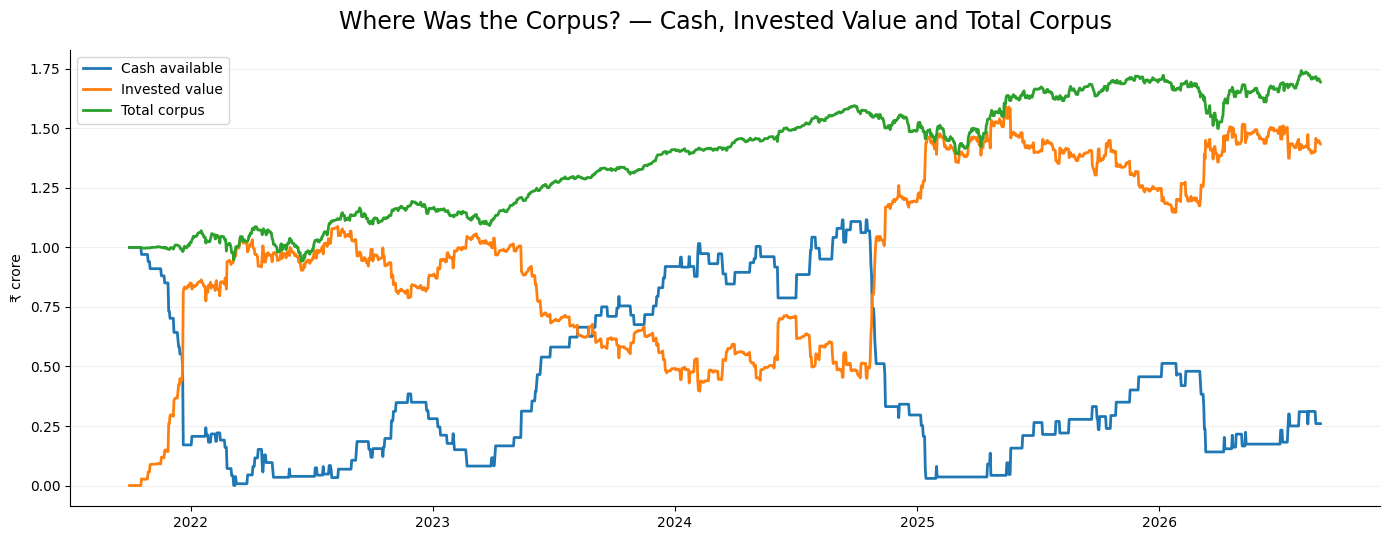

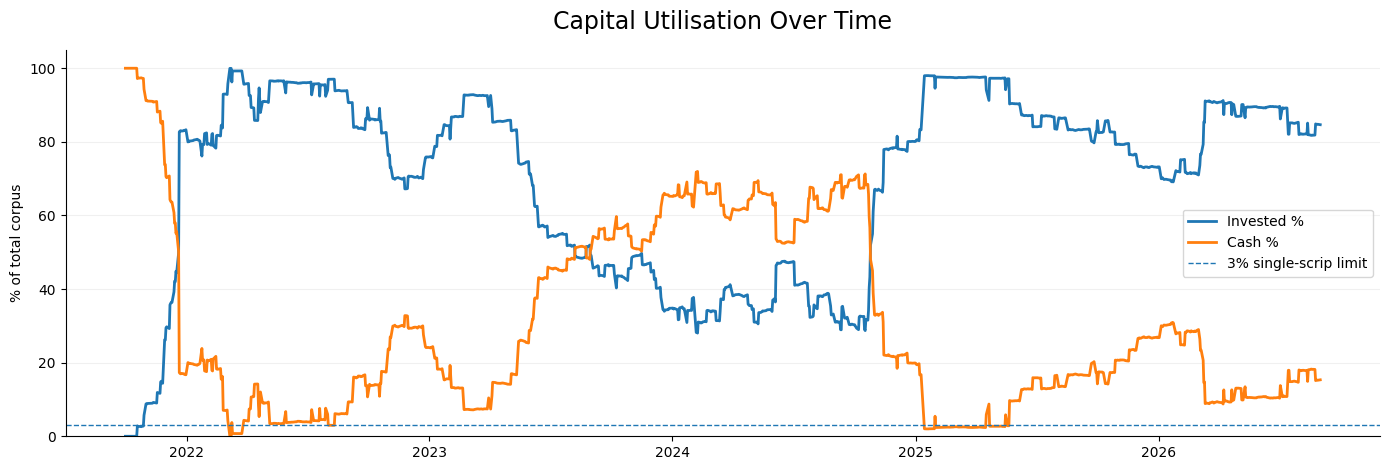

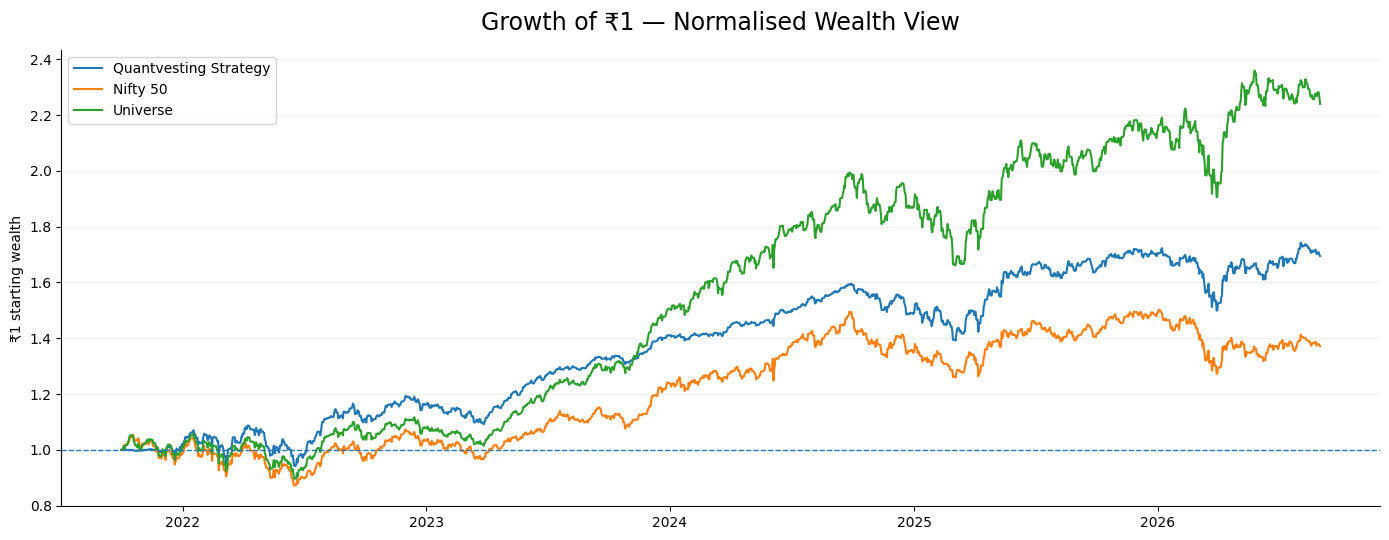


B. Breadth and capital-utilisation diagnostics


Measure,Value
% of observed dates strategy ahead of Nifty,97.0%
% of observed dates strategy ahead of Universe,39.0%
Average invested %,69.9%
Average cash %,30.1%
Maximum cash %,100.0%



C. Trade contribution concentration
Gross winning-trade P/L: ₹8,575,964
Gross losing-trade P/L:  ₹0
Net completed-trade P/L:  ₹8,575,964
Top 20% of completed positions' share of net completed-trade P/L: 28.5%

D. Interpretation framework

Use these views together rather than relying on CAGR alone:

1. Wealth outcome — final value and CAGR.
2. Path — whether the strategy spends long periods behind a passive alternative.
3. Capital utilisation — how much of the growing corpus was actually deployed.
4. Cash drag — how much capital remained idle while waiting for opportunities.
5. Trade quality — exit profit %, win rate and holding period.
6. Operational overhead — BUY/SELL events per year.
7. Concentration — whether the final result depends on a small number of positions.
8. Robustness — whether the strategy is ahead for a broad portion of the period,
   rather than only at the final date.

These are descriptive historical diagnostics. They do not by themselves determine
which approach s

In [14]:
# 15. Decision dashboard — where did the extra effort actually add value?

# Trade-level outcomes for the corrected common-start strategy.
comparison_trade_pairs = pd.DataFrame()
if not comparison_trades.empty:
    _open, _paired = {}, []
    for _, _tr in comparison_trades.sort_values(["symbol", "date", "event"]).iterrows():
        if _tr["event"] == "ENTRY":
            _open[_tr["symbol"]] = _tr.to_dict()
        elif _tr["event"] == "EXIT" and _tr["symbol"] in _open:
            _en = _open.pop(_tr["symbol"])
            _buy = float(_en["notional"]) + float(_en["cost"])
            _sell = float(_tr["notional"]) - float(_tr["cost"])
            _pnl = _sell - _buy
            _paired.append({
                "Symbol": _tr["symbol"],
                "Buy Date": pd.Timestamp(_en["date"]),
                "Sell Date": pd.Timestamp(_tr["date"]),
                "Trade P/L": _pnl,
                "Exit Profit %": _pnl / _buy if _buy else np.nan,
                "Holding Days": (
                    pd.Timestamp(_tr["date"]) - pd.Timestamp(_en["date"])
                ).days,
            })
    comparison_trade_pairs = pd.DataFrame(_paired)

if comparison_trade_pairs.empty:
    trade_stats = {
        "Completed exits": 0,
        "Winning exits": 0,
        "Win rate": np.nan,
        "Average exit return": np.nan,
        "Median exit return": np.nan,
        "Average winning return": np.nan,
        "Average losing return": np.nan,
        "Median holding days": np.nan,
    }
else:
    r = comparison_trade_pairs["Exit Profit %"].dropna()
    trade_stats = {
        "Completed exits": len(r),
        "Winning exits": int((r > 0).sum()),
        "Win rate": float((r > 0).mean()),
        "Average exit return": float(r.mean()),
        "Median exit return": float(r.median()),
        "Average winning return": float(r[r > 0].mean()) if (r > 0).any() else np.nan,
        "Average losing return": float(r[r < 0].mean()) if (r < 0).any() else np.nan,
        "Median holding days": float(comparison_trade_pairs["Holding Days"].median()),
    }

# Strategy deployment profile.
strategy_activity = strategy_slice.copy()
strategy_activity["invested_pct"] = np.where(
    strategy_activity["portfolio_value"] > 0,
    strategy_activity["invested_value"] / strategy_activity["portfolio_value"],
    np.nan,
)
strategy_activity["cash_pct"] = np.where(
    strategy_activity["portfolio_value"] > 0,
    strategy_activity["cash"] / strategy_activity["portfolio_value"],
    np.nan,
)

avg_invested_pct = float(strategy_activity["invested_pct"].mean())
avg_cash_pct = float(strategy_activity["cash_pct"].mean())
max_invested_pct = float(strategy_activity["invested_pct"].max())
max_cash_pct = float(strategy_activity["cash_pct"].max())

comparison_years = (comparison_end - comparison_start).days / 365.25
entries_per_year = len(strategy_entries) / comparison_years if comparison_years > 0 else np.nan
exits_per_year = len(strategy_exits) / comparison_years if comparison_years > 0 else np.nan

# Active value-add diagnostics.
nifty_final = float(comparison.loc[
    comparison["Approach"] == "Nifty 50 — Buy & Hold", "Final Value"
].iloc[0])
universe_final = float(comparison.loc[
    comparison["Approach"] == "Quantvesting Universe — Equal Weight Buy & Hold", "Final Value"
].iloc[0])

decision_summary = pd.DataFrame([{
    "Common Start": comparison_start.strftime("%d %b %Y"),
    "Common End": comparison_end.strftime("%d %b %Y"),
    "Strategy Final": strategy_end,
    "Nifty Final": nifty_final,
    "Universe Final": universe_final,
    "Strategy − Nifty (₹)": strategy_end - nifty_final,
    "Strategy − Universe (₹)": strategy_end - universe_final,
    "Strategy CAGR − Nifty (pp)": strategy_cagr - nifty_cagr,
    "Strategy CAGR − Universe (pp)": strategy_cagr - universe_cagr,
    "Avg Invested %": avg_invested_pct,
    "Avg Cash %": avg_cash_pct,
    "Max Invested %": max_invested_pct,
    "Max Cash %": max_cash_pct,
    "BUY / year": entries_per_year,
    "SELL / year": exits_per_year,
    "Completed Exits": trade_stats["Completed exits"],
    "Exit Win Rate": trade_stats["Win rate"],
    "Median Exit Profit %": trade_stats["Median exit return"],
    "Median Holding Days": trade_stats["Median holding days"],
}])

decision_display = decision_summary.copy()
for col in [
    "Strategy Final", "Nifty Final", "Universe Final",
    "Strategy − Nifty (₹)", "Strategy − Universe (₹)"
]:
    decision_display[col] = decision_display[col].map(lambda x: f"₹{x/1e7:.2f} Cr")
for col in [
    "Strategy CAGR − Nifty (pp)", "Strategy CAGR − Universe (pp)",
    "Avg Invested %", "Avg Cash %", "Max Invested %", "Max Cash %",
    "Exit Win Rate", "Median Exit Profit %"
]:
    decision_display[col] = decision_display[col].map(
        lambda x: f"{x:.1%}" if pd.notna(x) else "—"
    )
for col in ["BUY / year", "SELL / year", "Median Holding Days"]:
    decision_display[col] = decision_display[col].map(
        lambda x: f"{x:.1f}" if pd.notna(x) else "—"
    )

print("A. Decision summary — performance AND operational overhead")
display(decision_display.style.hide(axis="index"))

# 1) Capital deployment chart: this is the key answer to "where was my ₹1 Cr?"
fig, ax = plt.subplots(figsize=(14, 5.5))
ax.plot(corpus_view.index, corpus_view["Cash"] / 1e7, label="Cash available", linewidth=2)
ax.plot(corpus_view.index, corpus_view["Invested"] / 1e7, label="Invested value", linewidth=2)
ax.plot(corpus_view.index, corpus_view["Strategy Corpus"] / 1e7,
        label="Total corpus", linewidth=2)
ax.set_title("Where Was the Corpus? — Cash, Invested Value and Total Corpus",
             fontsize=17, pad=15)
ax.set_ylabel("₹ crore")
ax.grid(axis="y", alpha=0.18)
ax.spines[["top", "right"]].set_visible(False)
ax.legend()
fig.tight_layout()
plt.show()

# 2) Percentage deployment: easier to compare across a growing corpus.
fig, ax = plt.subplots(figsize=(14, 4.8))
ax.plot(strategy_activity["date"], strategy_activity["invested_pct"] * 100,
        label="Invested %", linewidth=2)
ax.plot(strategy_activity["date"], strategy_activity["cash_pct"] * 100,
        label="Cash %", linewidth=2)
ax.axhline(MAX_POSITION_PCT * 100, linestyle="--", linewidth=1,
           label="3% single-scrip limit")
ax.set_title("Capital Utilisation Over Time", fontsize=17, pad=15)
ax.set_ylabel("% of total corpus")
ax.set_ylim(0, 105)
ax.grid(axis="y", alpha=0.18)
ax.spines[["top", "right"]].set_visible(False)
ax.legend()
fig.tight_layout()
plt.show()

# 3) Strategy vs passive alternatives as a percentage of the same starting corpus.
relative = pd.DataFrame(index=comparison_paths.index)
relative["Strategy"] = comparison_paths["Quantvesting Strategy"] / INITIAL_CAPITAL
relative["Nifty 50"] = comparison_paths["Nifty 50 Buy & Hold"] / INITIAL_CAPITAL
relative["Universe"] = comparison_paths["Universe Equal-Weight Buy & Hold"] / INITIAL_CAPITAL

fig, ax = plt.subplots(figsize=(14, 5.5))
ax.plot(relative.index, relative["Strategy"], label="Quantvesting Strategy")
ax.plot(relative.index, relative["Nifty 50"], label="Nifty 50")
ax.plot(relative.index, relative["Universe"], label="Universe")
ax.axhline(1.0, linestyle="--", linewidth=1)
ax.set_title("Growth of ₹1 — Normalised Wealth View", fontsize=17, pad=15)
ax.set_ylabel("₹1 starting wealth")
ax.grid(axis="y", alpha=0.18)
ax.spines[["top", "right"]].set_visible(False)
ax.legend()
fig.tight_layout()
plt.show()

# 4) How often was the strategy actually ahead?
ahead_of_nifty = float(
    (comparison_paths["Quantvesting Strategy"] >
     comparison_paths["Nifty 50 Buy & Hold"]).mean()
)
ahead_of_universe = float(
    (comparison_paths["Quantvesting Strategy"] >
     comparison_paths["Universe Equal-Weight Buy & Hold"]).mean()
)

breadth = pd.DataFrame([{
    "Measure": "% of observed dates strategy ahead of Nifty",
    "Value": ahead_of_nifty,
}, {
    "Measure": "% of observed dates strategy ahead of Universe",
    "Value": ahead_of_universe,
}, {
    "Measure": "Average invested %",
    "Value": avg_invested_pct,
}, {
    "Measure": "Average cash %",
    "Value": avg_cash_pct,
}, {
    "Measure": "Maximum cash %",
    "Value": max_cash_pct,
}])
breadth["Value"] = breadth["Value"].map(lambda x: f"{x:.1%}")
print()
print("B. Breadth and capital-utilisation diagnostics")
display(breadth.style.hide(axis="index"))

# 5) Trade contribution — identify whether results depend on a handful of exits.
if not comparison_trade_pairs.empty:
    contrib = comparison_trade_pairs.sort_values("Trade P/L", ascending=False).copy()
    total_positive = contrib.loc[contrib["Trade P/L"] > 0, "Trade P/L"].sum()
    total_negative = contrib.loc[contrib["Trade P/L"] < 0, "Trade P/L"].sum()

    print()
    print("C. Trade contribution concentration")
    print(f"Gross winning-trade P/L: ₹{total_positive:,.0f}")
    print(f"Gross losing-trade P/L:  ₹{total_negative:,.0f}")
    print(f"Net completed-trade P/L:  ₹{(total_positive + total_negative):,.0f}")

    top_n = max(1, int(np.ceil(len(contrib) * 0.20)))
    top_trade_share = (
        contrib.head(top_n)["Trade P/L"].sum() /
        contrib["Trade P/L"].sum()
        if contrib["Trade P/L"].sum() != 0 else np.nan
    )
    print(f"Top 20% of completed positions' share of net completed-trade P/L: "
          f"{top_trade_share:.1%}" if pd.notna(top_trade_share) else
          "Top 20% contribution cannot be calculated.")

# 6) Position ledger remains the detailed audit trail.
print()
print("D. Interpretation framework")
print("""
Use these views together rather than relying on CAGR alone:

1. Wealth outcome — final value and CAGR.
2. Path — whether the strategy spends long periods behind a passive alternative.
3. Capital utilisation — how much of the growing corpus was actually deployed.
4. Cash drag — how much capital remained idle while waiting for opportunities.
5. Trade quality — exit profit %, win rate and holding period.
6. Operational overhead — BUY/SELL events per year.
7. Concentration — whether the final result depends on a small number of positions.
8. Robustness — whether the strategy is ahead for a broad portion of the period,
   rather than only at the final date.

These are descriptive historical diagnostics. They do not by themselves determine
which approach should be chosen.
""")


# 6. Quick sensitivity check

We vary only the **ATH Gap entry threshold**.

This is not parameter optimization. It is a sanity check:

> Does the strategy's behaviour change in a broadly understandable way when we require more or less distance from ATH?


In [15]:
# 12. Threshold sensitivity
rows = []

for threshold in [0.10, 0.15, 0.20, 0.25, 0.30]:
    old = ENTRY_ATH_GAP
    # Small wrapper keeps the engine logic unchanged.
    ENTRY_ATH_GAP = threshold
    p, t = run_backtest(prices)
    end_val = float(p["portfolio_value"].iloc[-1])
    dd = (p["portfolio_value"] / p["portfolio_value"].cummax() - 1).min()

    rows.append({
        "ATH gap required": f"{threshold:.0%}",
        "Ending value": f"₹{end_val/1e7:.2f} Cr",
        "Total return": f"{end_val/INITIAL_CAPITAL - 1:.1%}",
        "Max drawdown": f"{dd:.1%}",
        "Entries": int((t["event"] == "ENTRY").sum()) if not t.empty else 0,
    })

ENTRY_ATH_GAP = 0.20

sensitivity = pd.DataFrame(rows)
display(sensitivity.style.hide(axis="index"))


ATH gap required,Ending value,Total return,Max drawdown,Entries
10%,₹1.80 Cr,80.2%,-15.3%,255
15%,₹1.76 Cr,76.3%,-14.4%,188
20%,₹1.69 Cr,69.5%,-13.3%,142
25%,₹1.73 Cr,72.8%,-13.4%,118
30%,₹1.69 Cr,69.1%,-12.3%,97


# 7. Final audit

These checks are about **implementation correctness**, not profitability.

A passing audit means the prototype followed the intended event sequence. It does not mean the strategy is validated.


In [16]:
# 13. No-look-ahead and integrity audit
audit = {}

audit["All configured securities loaded"] = set(prices["symbol"]) == set(signals_config["symbol"])
audit["No duplicate price rows"] = prices.duplicated(["symbol","date"]).sum() == 0
audit["No invalid OHLC"] = quality["Invalid OHLC rows"] == 0
audit["Portfolio produced"] = not portfolio.empty

# Position-size guardrail audit.
# The engine records the pre-entry portfolio value and the resulting position
# percentage, so the constraint can be checked directly without re-running logic.
if not trades.empty and "position_pct_before_entry" in trades.columns:
    entry_positions = trades[trades["event"] == "ENTRY"]
    audit["3% single-scrip guardrail"] = bool(
        (entry_positions["position_pct_before_entry"] <= MAX_POSITION_PCT + 1e-12).all()
    )
else:
    audit["3% single-scrip guardrail"] = bool(0 < MAX_POSITION_PCT <= 0.03)

if not entries.empty:
    entries2 = entries.copy()
    entries2["signal_date"] = pd.to_datetime(entries2["signal_date"])
    entries2["date"] = pd.to_datetime(entries2["date"])

    audit["Every entry follows its signal"] = bool((entries2["signal_date"] < entries2["date"]).all())

    def expected_open(row):
        g = prices[prices["symbol"] == row["symbol"]].sort_values("date")
        future = g[g["date"] > row["signal_date"]]
        return float(future.iloc[0]["Open"]) if not future.empty else np.nan

    entries2["expected_next_open"] = entries2.apply(expected_open, axis=1)
    entries2["entry_price_before_slippage"] = entries2["price"] / (1 + SLIPPAGE_BPS/10_000)

    audit["Every entry uses next trading-day open"] = bool(np.isclose(
        entries2["entry_price_before_slippage"],
        entries2["expected_next_open"],
        rtol=1e-8, atol=1e-8
    ).all())

    audit["Entry ATH is frozen from signal date"] = bool(
        np.allclose(
            entries2["entry_ath"],
            entries2.apply(
                lambda r: float(
                    prices[
                        (prices["symbol"] == r["symbol"]) &
                        (prices["date"] == r["signal_date"])
                    ]["running_ath"].iloc[0]
                ),
                axis=1
            ),
            rtol=0, atol=1e-8
        )
    )
else:
    audit["Every entry follows its signal"] = True
    audit["Every entry uses next trading-day open"] = True
    audit["Entry ATH is frozen from signal date"] = True

# Corpus accounting audits for the corrected sizing model.
if not portfolio.empty:
    audit["Cash never negative"] = bool((portfolio["cash"] >= -1e-7).all())
    audit["Invested never exceeds corpus"] = bool(
        (portfolio["invested_value"] <= portfolio["portfolio_value"] + 1e-7).all()
    )
    audit["Cash + invested = corpus"] = bool(
        np.allclose(
            portfolio["cash"] + portfolio["invested_value"],
            portfolio["portfolio_value"],
            rtol=0,
            atol=1e-7,
        )
    )
else:
    audit["Cash never negative"] = True
    audit["Invested never exceeds corpus"] = True
    audit["Cash + invested = corpus"] = True

audit_table = pd.DataFrame([
    {"Audit": k, "Result": "✓ PASS" if v else "✗ FAIL"}
    for k,v in audit.items()
])

display(audit_table.style.hide(axis="index"))


Audit,Result
All configured securities loaded,✓ PASS
No duplicate price rows,✓ PASS
No invalid OHLC,✓ PASS
Portfolio produced,✓ PASS
3% single-scrip guardrail,✓ PASS
Every entry follows its signal,✓ PASS
Every entry uses next trading-day open,✓ PASS
Entry ATH is frozen from signal date,✓ PASS
Cash never negative,✓ PASS
Invested never exceeds corpus,✓ PASS


# 16. Interpretation

This notebook keeps the original engine intact and adds an analysis layer around it.

### Strategy mechanics
- Up to `MAX_HOLDINGS = 35` concurrent positions.
- No single scrip can receive more than `MAX_POSITION_PCT = 3%` of the TOTAL CORPUS (cash + invested value) known immediately before entry.
- Existing ATH → ATH Gap → EOD signal → T+1 execution → frozen ATH exit → accounting logic is unchanged.

### What the new analysis answers
1. **Did the rules actually trade as intended?** — chronological BUY/SELL ledger.
2. **How did each exited position perform?** — net `Exit Profit %` plus rupee P/L.
3. **What if the same ₹1 crore had simply stayed in Nifty 50?**
4. **What if it had simply been equally invested across the Quantvesting universe?**
5. **Are all three comparisons genuinely apples-to-apples?** — one common start date.
6. **What is the operational overhead?** — transaction frequency, cash held, hit rate and trade contribution.

All three approaches start on the same first Nifty trading day on/after START_DATE. Universe slices for unavailable securities remain in cash until first availability. The comparison is historical and hypothetical. It does not by itself establish future performance or account for every real-world implementation effect.
